In [1]:
import os
import numpy as np
# uncomment to disable NVIDIA GPUs
#os.environ['CUDA_VISIBLE_DEVICES'] = ''
# or pick the device (cpu, gpu, and tpu)
#os.environ['JAX_PLATFORMS'] = 'cpu'

# change JAX GPU memory preallocation fraction
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.95'

# you do not want this
#os.environ['XLA_FLAGS'] = '--xla_gpu_deterministic_ops=true'

import jax

import jax.numpy as jnp
from jax import jit, lax
#jax.print_environment_info()

!nvidia-smi --query-gpu=gpu_name --format=csv,noheader


NVIDIA GeForce GTX 1060 6GB


In [2]:
import matplotlib.pyplot as plt
import matplotlib_inline


matplotlib_inline.backend_inline.set_matplotlib_formats('jpeg')

from pmwd import (
    Configuration,
    Cosmology, SimpleLCDM,
    boltzmann, linear_power, growth,
    white_noise, linear_modes,
    lpt,
    nbody,
    scatter,
)
from pmwd.pm_util import fftinv
from pmwd.spec_util import powspec
from pmwd.vis_util import simshow

In [3]:
if jax.default_backend() == 'gpu':
    ptcl_spacing = 1.  # Lagrangian space Cartesian particle grid spacing, in Mpc/h by default
    ptcl_grid_shape = (128,) * 3
else:
    ptcl_spacing = 4.
    ptcl_grid_shape = (64,) * 3

conf = Configuration(ptcl_spacing, ptcl_grid_shape, mesh_shape=2)  # 2x mesh shape

print(conf)  # with other default parameters
print(f'\n Simulating {conf.ptcl_num} particles with a {conf.mesh_shape} mesh for {conf.a_nbody_num} time steps.')

Configuration(ptcl_spacing=1.0,
              ptcl_grid_shape=(128, 128, 128),
              mesh_shape=(256, 256, 256),
              cosmo_dtype=dtype('float64'),
              pmid_dtype=dtype('int16'),
              float_dtype=dtype('float32'),
              k_pivot_Mpc=0.05,
              T_cmb=2.7255,
              M=1.98847e+40,
              L=3.0856775815e+22,
              T=3.0856775815e+17,
              transfer_fit=True,
              transfer_fit_nowiggle=False,
              transfer_lgk_min=-4,
              transfer_lgk_max=3,
              transfer_lgk_maxstep=0.0078125,
              growth_rtol=1.4901161193847656e-08,
              growth_atol=1.4901161193847656e-08,
              growth_inistep=(1, None),
              lpt_order=2,
              a_start=0.015625,
              a_stop=1,
              a_lpt_maxstep=0.0078125,
              a_nbody_maxstep=0.015625,
              symp_splits=((0, 0.5), (1, 0.5)),
              chunk_size=16777216)

 Simulating 2097

In [4]:
def nolin_ps(cosmo, modes):
    cosmo = jax.block_until_ready(boltzmann(cosmo, conf))
    modes = linear_modes(modes, cosmo, conf)
    ptcl, obsvbl = jax.block_until_ready(lpt(modes, cosmo, conf))
    ptcl, obsvbl = jax.block_until_ready(nbody(ptcl, obsvbl, cosmo, conf))
    dens = scatter(ptcl, conf)
    return powspec(dens, conf.cell_size)[:2]
"""
cosmology = Cosmology(conf, A_s_1e9=2.0, n_s=0.96, Omega_m=0.3, Omega_b=0.05, h=0.7, xi_= 0.0, w_0_ =-1.0)
modes = white_noise(0, conf)

xis = [-0.9, -0.8, -0.7, -0.6 -0.5, -0.4, -0.3, -0.2, -0.1, 0.0, +0.1, +0.2, +0.3, +0.4, +0.5, +0.6, +0.7, +0.8, +0.9]
fig, ax = plt.subplots()
for xi in xis:
    cosmo = cosmology.replace(xi_=xi)
    k, P   = nolin_ps(cosmo, modes)
    ax.loglog(k, P)
ax.set(xlabel='k', ylabel='P(k)')
ax.legend()
plt.grid(True, which='both', ls='--', lw=0.5, color='gray')
plt.figure(figsize=(24, 18), dpi=100)
plt.show()
"""

"\ncosmology = Cosmology(conf, A_s_1e9=2.0, n_s=0.96, Omega_m=0.3, Omega_b=0.05, h=0.7, xi_= 0.0, w_0_ =-1.0)\nmodes = white_noise(0, conf)\n\nxis = [-0.9, -0.8, -0.7, -0.6 -0.5, -0.4, -0.3, -0.2, -0.1, 0.0, +0.1, +0.2, +0.3, +0.4, +0.5, +0.6, +0.7, +0.8, +0.9]\nfig, ax = plt.subplots()\nfor xi in xis:\n    cosmo = cosmology.replace(xi_=xi)\n    k, P   = nolin_ps(cosmo, modes)\n    ax.loglog(k, P)\nax.set(xlabel='k', ylabel='P(k)')\nax.legend()\nplt.grid(True, which='both', ls='--', lw=0.5, color='gray')\nplt.figure(figsize=(24, 18), dpi=100)\nplt.show()\n"

In [5]:
rho_crit = conf.rho_crit
print(rho_crit)

27.752823482245116


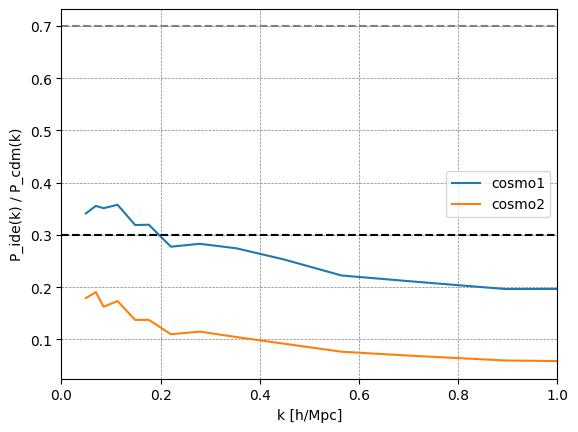

In [6]:
seed      = 1
modes    = white_noise(seed, conf)


cosmoR =       Cosmology(conf, A_s_1e9=2.1, n_s=0.96, Omega_m=0.31, Omega_b=0.05, h=0.67, xi_=-0.1, w_0_=-1.0, w_a_= 0.0)
cosmo_cdm =    Cosmology(conf, A_s_1e9=2.1, n_s=0.96, Omega_m=0.31, Omega_b=0.05, h=0.67, xi_=0.0, w_0_=-1.0, w_a_= 0.0)
cosmo1 =       Cosmology(conf, A_s_1e9=2.1, n_s=0.96, Omega_m=0.29, Omega_b=0.05, h=0.68, xi_=-0.1, w_0_=-1.0, w_a_=0.0)
cosmo2 =       Cosmology(conf, A_s_1e9=2.1, n_s=0.96, Omega_m=0.22, Omega_b=0.05, h=0.71, xi_=-0.1, w_0_=-1.0, w_a_=0.0)


fig, ax = plt.subplots()


k_r, p_r = nolin_ps(cosmoR, modes)
k_ref, P_ref = nolin_ps(cosmo_cdm, modes)
k1, p1 = nolin_ps(cosmo1, modes)
k2, p2 = nolin_ps(cosmo2, modes)



ax.plot(k1, p1/P_ref, label='cosmo1')
ax.plot(k2, p2/P_ref, label='cosmo2')

#ax.set_xscale('log')
ax.set_xlim(0 , 1)
ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('P_ide(k) / P_cdm(k)')
ax.axhline(0.7, color='gray', linestyle='--')
ax.axhline(0.3, color='black', linestyle='--')
ax.legend()
plt.grid(True, which='both', ls='--', lw=0.5, color='gray')
plt.show()

In [41]:
r = 0.0410 * P_ref**1.2583

r1 = p1 / r
fig, ax = plt.subplots()
ax.plot(k1, r1, label='cosmo R')

ax.set_xlim(0 , 1)
ax.set_ylim(0.8 , 1.2)
ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('P_ide(k) / P_cdm(k)')
ax.axhline(1.02, color='gray', linestyle='--')
ax.axhline(0.98, color='black', linestyle='--')
ax.legend()
plt.grid(True, which='both', ls='--', lw=0.5, color='gray')
plt.show()

TypeError: div got incompatible shapes for broadcasting: (0,), (21,).

In [8]:
p_range = P_ref[7:13]
print(p_range)

[1364.748 1045.585  811.242  651.577  510.046  406.073]


In [10]:
p_range = P_ref[5:13]
pr_range = p_r[5:13]

p1_l = p1[5:13]
p2_l = p2[5:13]
for i in np.arange(0.001, 1.999, 0.001):
    for j in np.arange(0.500, 1.900, 0.001):

        #i /= 100.0
        #j = j / 1000.0
        #print(f'Trying: {i}, {j}')
        r = i * p_range**j
        r1 = pr_range / r
        r1_l = p1_l / r
        r2_l = p2_l / r
        if np.all(r1 > 0.97) and np.all(r1 < 1.03):
            print(f'Found: {i}, {j} em r1')
        elif np.all(r1_l > 0.97) and np.all(r1_l < 1.03):
            print(f'Found: {i}, {j} em r1_l')
        elif np.all(r2_l > 0.97) and np.all(r2_l < 1.03):
            print(f'Found: {i}, {j} em r2_l')
            

KeyboardInterrupt: 

In [40]:
import numpy as np
import jax.numpy as jnp

# ——— Carregue seus dados aqui ———
# Exemplo: substitua pelas suas variáveis reais
#P_ref = np.array([/* ... seus valores ... */])
#p_r   = np.array([/* ... seus valores ... */])
#p1    = np.array([/* ... seus valores ... */])
#p2    = np.array([/* ... seus valores ... */])

# ——— Converte e fatia para JAX ———
p_range = jnp.array(P_ref[6:13])   # shape (8,)
pr_range = jnp.array(p_r[6:13])
p1_l     = jnp.array(p1[6:13])
p2_l     = jnp.array(p2[6:13])

# ——— Vetores de i e j ———
i_vals = jnp.arange(8.001, 9.000, 0.001)   # shape (1998,)
j_vals = jnp.arange(0.001, 1.000, 0.001)   # shape (1400,)

# ——— Gera grade 2D ———
# I e J terão shape (1998, 1400)
I, J = jnp.meshgrid(i_vals, j_vals, indexing="ij")

# ——— Expande dimensões para aplicar o broadcasting ———
# p_range vira (1,1,8), I e J viram (1998,1400,1)
p_ex = p_range[jnp.newaxis, jnp.newaxis, :]

#R    = I[:, :, jnp.newaxis] * p_ex ** (J[:, :, jnp.newaxis])                       # a*x^b
R = I[:, :, jnp.newaxis] + J[:, :, jnp.newaxis] * p_ex                             # a + bx
#R = I[:, :, jnp.newaxis] * jnp.exp(J[:, :, jnp.newaxis] * p_ex)                    # a * exp(b*x)
#R = I[:, :, jnp.newaxis] + J[:, :, jnp.newaxis] * jnp.log(p_ex)                    # a + b*log(x)
#R = I[:, :, jnp.newaxis] * p_ex / (J[:, :, jnp.newaxis] + p_ex)                     # a * x / (b + x)
#R = I[:, :, jnp.newaxis] / (1 + J[:, :, jnp.newaxis] * p_ex)



# ——— Calcula todas as razões de uma vez ———
R1   = pr_range[jnp.newaxis, jnp.newaxis, :] / R
R1_l = p1_l    [jnp.newaxis, jnp.newaxis, :] / R
R2_l = p2_l    [jnp.newaxis, jnp.newaxis, :] / R

# ——— Cria máscaras booleanas (True onde TODAS as 8 componentes satisfazem) ———
mask_r1   = jnp.all((R1   > 0.95) & (R1   < 1.05), axis=2)
mask_r1_l = jnp.all((R1_l > 0.95) & (R1_l < 1.05), axis=2)
mask_r2_l = jnp.all((R2_l > 0.95) & (R2_l < 1.05), axis=2)

# ——— Extrai índices de i,j que satisfazem ———
idx_r1   = jnp.argwhere(mask_r1)    # shape (N1, 2)
idx_r1_l = jnp.argwhere(mask_r1_l)  # shape (N2, 2)
idx_r2_l = jnp.argwhere(mask_r2_l)  # shape (N3, 2)

# ——— Imprime resultados ———
if idx_r1.shape[0] > 0:
    for (i0, j0) in idx_r1:
        print(f'Found r1: i={float(i_vals[i0])}, j={float(j_vals[j0])}')
else:
    print('Nenhum resultado em r1.')

if idx_r1_l.shape[0] > 0:
    for (i0, j0) in idx_r1_l:
        print(f'Found r1_l: i={float(i_vals[i0])}, j={float(j_vals[j0])}')
else:
    print('Nenhum resultado em r1_l.')

if idx_r2_l.shape[0] > 0:
    for (i0, j0) in idx_r2_l:
        print(f'Found r2_l: i={float(i_vals[i0])}, j={float(j_vals[j0])}')
else:
    print('Nenhum resultado em r2_l.')


TypeError: div got incompatible shapes for broadcasting: (1, 1, 0), (1000, 999, 7).

In [33]:
p_range = P_ref[5:13]
p1 = p1[5:13]
print(p_range)
print(p1)
print(k_ref[5:13])

[2654.491 1936.852 1364.748 1045.585  811.242  651.577  510.046  406.073]
[]
[0.176 0.221 0.279 0.353 0.448 0.565 0.71  0.896]
